# Demonstration of Sentinel-2 Vegetation Cover Prediction Maps (Eastern Morocco)

##  Overview

This notebook is used to visualize and post-process Sentinel-2-based vegetation cover prediction maps across Eastern Morocco.
The workflow focuses on loading, inspecting, and analyzing yearly prediction outputs generated from Google Earth Engine.

---

## Data Source

- The prediction maps were generated in **Google Earth Engine (GEE)**
- Each yearly map is derived from a **Sentinel-2 yearly median composite**
- Random Forest regression was used to estimate vegetation-related response variables based on nine spectral indices

---

## Data Characteristics

- Spatial resolution: **10 m**
- Temporal resolution: **Yearly (2017–2025)**
- Coverage: **Eastern Morocco working region**
- Format: **GeoTIFF tiles exported from GEE**

---

## Important Notes / Limitations

- These prediction maps are intended for **quantitative and comparative analysis**
- Outputs represent **model-derived estimates**
- Accuracy depends on:
  - Training data quality
  - Representativeness of Sentinel-2 yearly composites
- Results should be interpreted as **relative vegetation patterns and trends**, rather than absolute vegetation cover as yearly composites were used

---

## Intended Use

These datasets are suitable for:
- Regional vegetation trend analysis
- Spatial comparison across years
- Detecting broad-scale ecosystem changes

They are **not designed for fine-scale ecological inventory or precise vegetation quantification**.

---

## Workflow Summary

1. Sentinel-2 data preprocessing (cloud masking + spectral indices)
2. Yearly median compositing in GEE
3. Random Forest regression modeling
4. Yearly prediction map generation
5. Export as GeoTIFF for local analysis
6. Post-processing and visualization in Python (this notebook)

---

Tiles found: 2
['S2_RF_EM_2018-0000000000-0000000000.tif', 'S2_RF_EM_2018-0000000000-0000032768.tif']


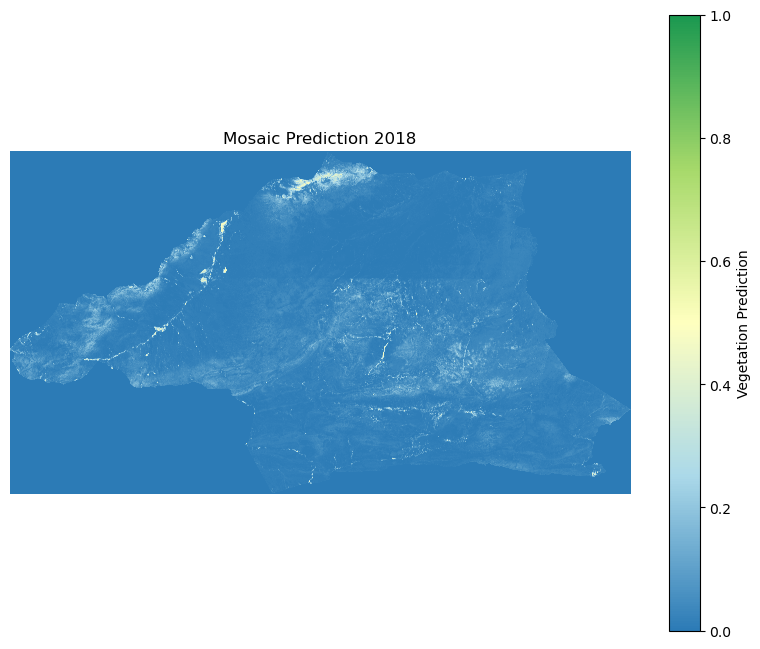

In [1]:
import rasterio
from rasterio.merge import merge
import numpy as np
import os
import matplotlib.pyplot as plt

# -----------------------------
# Folder of Downloaded GEE_VEG_Predictions
# -----------------------------
folder = r'C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM'
year = 2018

# -----------------------------
# Example of 2018
# -----------------------------
tif_files = [
    f for f in os.listdir(folder)
    if f.endswith(".tif") and str(year) in f
]

tif_files.sort()

print("Tiles found:", len(tif_files))
print(tif_files)

# -----------------------------
# Open all raster files
# -----------------------------
src_files = [
    rasterio.open(os.path.join(folder, f))
    for f in tif_files
]

# -----------------------------
# Mosaic
# -----------------------------
mosaic, out_transform = merge(src_files)

# Close files
for src in src_files:
    src.close()

# -----------------------------
# Convert to 2D
# -----------------------------
mosaic = mosaic[0].astype("float32")

# -----------------------------
# Replace NaN --> -1
# -----------------------------
mosaic = np.where(np.isnan(mosaic), -1, mosaic)

# Optional: also treat masked values
mosaic = np.nan_to_num(mosaic, nan=-1)

# -----------------------------
# Custom color palette
# -----------------------------
from matplotlib.colors import LinearSegmentedColormap

colors = [
    "#2c7bb6",  # blue (low)
    "#abd9e9",  # light blue
    "#ffffbf",  # yellow
    "#a6d96a",  # light green
    "#1a9850",  # green (high)
]

cmap = LinearSegmentedColormap.from_list("veg_palette", colors)

# -----------------------------
# Plot mosaic
# -----------------------------
plt.figure(figsize=(10, 8))

img = plt.imshow(
    mosaic,
    cmap=cmap,
    vmin=0,     #
    vmax=1      #
)

cbar = plt.colorbar(img)
cbar.set_label("Vegetation Prediction")

plt.title(f"Mosaic Prediction {year}")
plt.axis("off")
plt.show()


Tiles found: 2
['S2_RF_EM_2017-0000000000-0000000000.tif', 'S2_RF_EM_2017-0000000000-0000032768.tif']


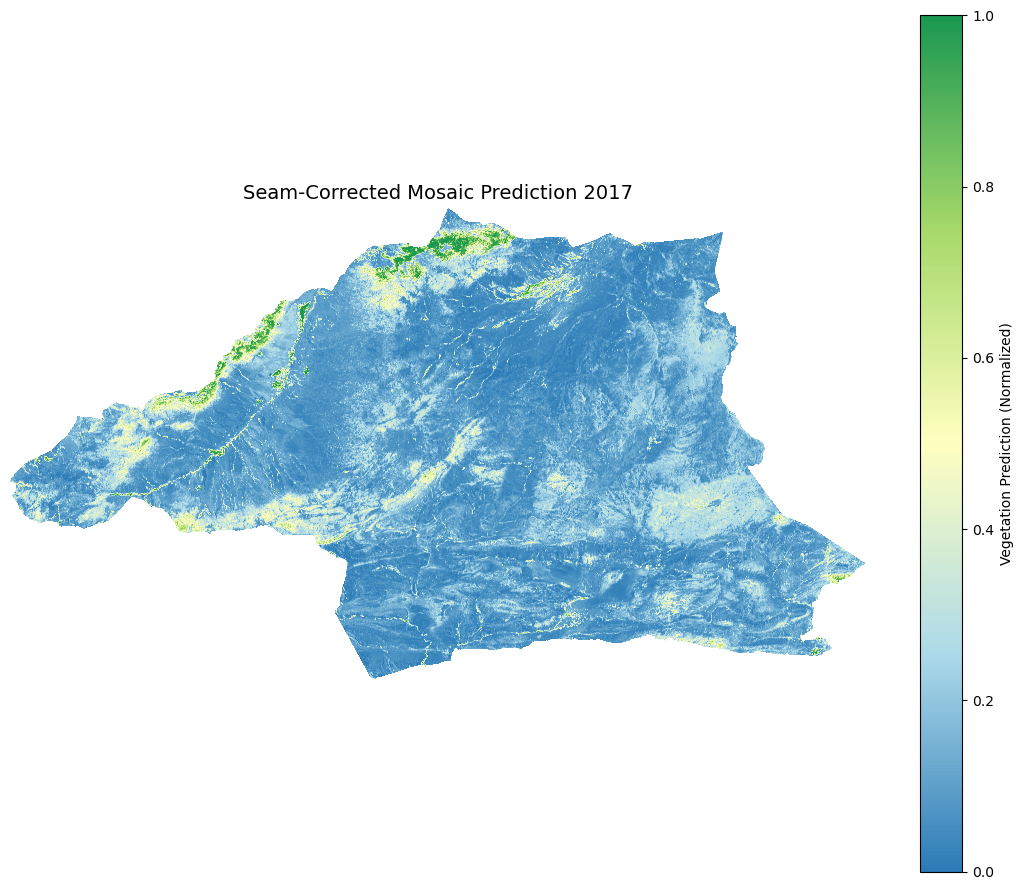

Raw min/max: -1.0 0.5001551
Vmin/Vmax used: 0.003174228360876441 0.09639903157949448


In [5]:
import rasterio
from rasterio.merge import merge
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =====================================================
# 1. INPUT SETTINGS
# =====================================================
folder = r'C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM'
year = 2017

# =====================================================
# 2. FILTER FILES
# =====================================================
tif_files = [
    f for f in os.listdir(folder)
    if f.endswith(".tif") and str(year) in f
]

tif_files.sort()

print(f"Tiles found: {len(tif_files)}")
print(tif_files)

# =====================================================
# 3. OPEN RASTERS
# =====================================================
src_files = [
    rasterio.open(os.path.join(folder, f))
    for f in tif_files
]

# =====================================================
# 4. MOSAIC (IMPORTANT FIX: use mean blending)
# =====================================================
mosaic, out_transform = merge(
    src_files,
    method="first" 
)

# close files
for src in src_files:
    src.close()

# =====================================================
# 5. CLEAN DATA
# =====================================================
mosaic = mosaic[0].astype("float32")

# standardize nodata
mosaic = np.where(np.isnan(mosaic), -1, mosaic)
mosaic = np.nan_to_num(mosaic, nan=-1)

# =====================================================
# 6. MASK NODATA FOR VISUALIZATION
# =====================================================
mosaic_masked = np.ma.masked_where(mosaic == -1, mosaic)

# =====================================================
# 7. GLOBAL NORMALIZATION
# =====================================================
valid = mosaic_masked[~mosaic_masked.mask]

vmin = np.percentile(valid, 2)
vmax = np.percentile(valid, 98)

mosaic_norm = (mosaic_masked - vmin) / (vmax - vmin)
mosaic_norm = np.clip(mosaic_norm, 0, 1)

# =====================================================
# 8. COLOR PALETTE (VEGETATION STYLE)
# =====================================================
colors = [
    "#2c7bb6",  # low (blue)
    "#abd9e9",  # low-mid
    "#ffffbf",  # neutral
    "#a6d96a",  # greenish
    "#1a9850"   # high (green)
]

cmap = LinearSegmentedColormap.from_list("veg_palette", colors)

# =====================================================
# 9. PLOT
# =====================================================
plt.figure(figsize=(11, 9))

img = plt.imshow(
    mosaic_norm,
    cmap=cmap,
    vmin=0,
    vmax=1
)

cbar = plt.colorbar(img)
cbar.set_label("Vegetation Prediction (Normalized)")

plt.title(f"Seam-Corrected Mosaic Prediction {year}", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

# =====================================================
# 10. OPTIONAL DEBUG (CHECK RANGE)
# =====================================================
print("Raw min/max:", np.nanmin(mosaic), np.nanmax(mosaic))
print("Vmin/Vmax used:", vmin, vmax)

In [6]:
# -----------------------------
# Export/Save the mosica
# -----------------------------
from rasterio.transform import Affine

out_dir = os.path.join(folder, "mosaic")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"S2_RF_EM_{year}.tif")

# get metadata from first tile
with rasterio.open(os.path.join(folder, tif_files[0])) as src:
    meta = src.meta.copy()

meta.update({
    "height": mosaic.shape[0],
    "width": mosaic.shape[1],
    "transform": out_transform,
    "nodata": -1,
    "dtype": "float32"
})

with rasterio.open(out_path, "w", **meta) as dst:
    dst.write(mosaic, 1)

print("Saved:", out_path)

Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\mosaic\S2_RF_EM_2017.tif



Processing Year: 2025
Input: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\S2_RF_EM_2025.tif
Shape: (8138, 14749)
Original nodata: None
NaN replaced: 53242408
Saved: C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\S2_RF_EM_2025_masked.tif


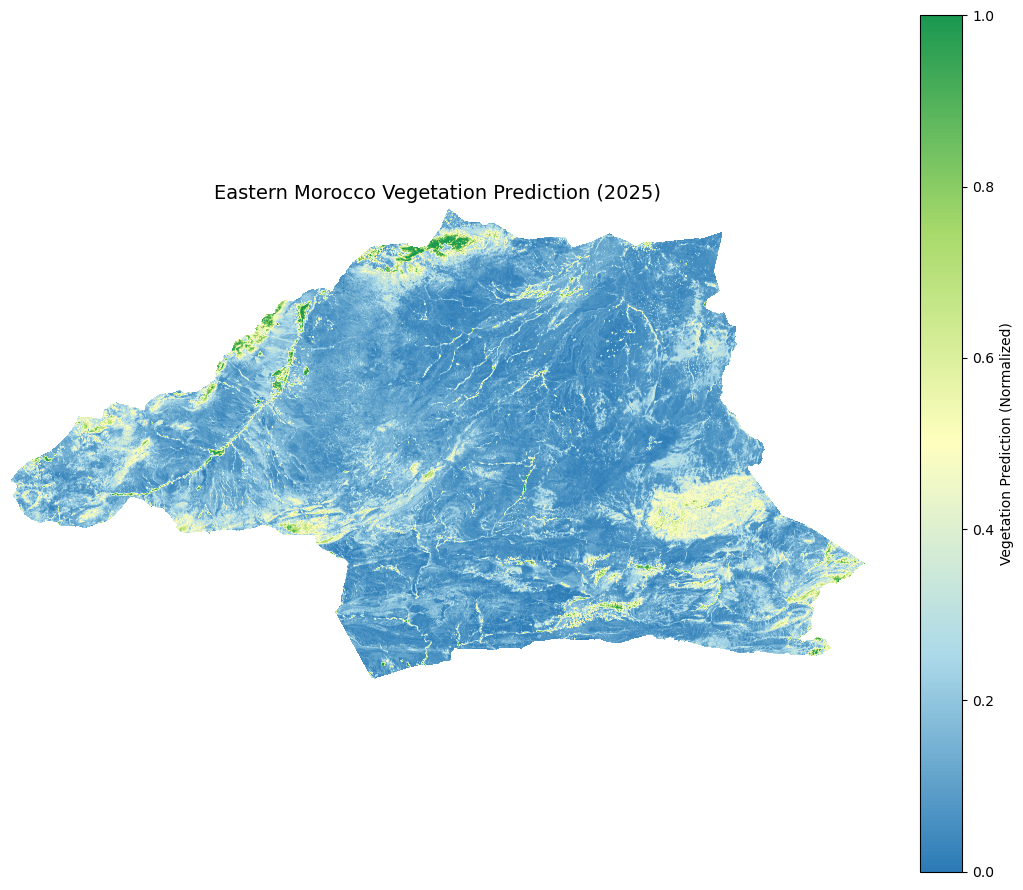

Raw min/max: -1.0 0.5001551
Normalization range: 0.002571339993737638 0.06277414888143529

All years processed successfully.


In [14]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =====================================================
# 1. INPUT SETTINGS
# =====================================================
folder = r'C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m'

# Years already downloaded as mosaicked TIFFs
years = range(2017, 2026)

# =====================================================
# 2. OUTPUT FOLDER
# =====================================================
out_dir = os.path.join(folder, "30m_masked")
os.makedirs(out_dir, exist_ok=True)

# =====================================================
# 3. COLOR PALETTE
# =====================================================
colors = [
    "#2c7bb6",  # blue
    "#abd9e9",  # light blue
    "#ffffbf",  # yellow
    "#a6d96a",  # light green
    "#1a9850"   # green
]

cmap = LinearSegmentedColormap.from_list(
    "veg_palette",
    colors
)

# =====================================================
# 4. LOOP THROUGH YEARS
# =====================================================
for year in years:

    print("\n===================================")
    print(f"Processing Year: {year}")
    print("===================================")

    # -------------------------------------------------
    # Find yearly TIFF
    # -------------------------------------------------
    tif_files = [
        f for f in os.listdir(folder)
        if f.endswith(".tif") and str(year) in f
    ]

    tif_files.sort()

    if len(tif_files) == 0:
        print(f"No TIFF found for {year}")
        continue

    # Assume one mosaicked TIFF per year
    tif_path = os.path.join(folder, tif_files[0])

    print("Input:", tif_path)

    # -------------------------------------------------
    # Read raster
    # -------------------------------------------------
    with rasterio.open(tif_path) as src:

        data = src.read(1).astype("float32")

        meta = src.meta.copy()

        print("Shape:", data.shape)
        print("Original nodata:", src.nodata)

    # -------------------------------------------------
    # Replace NaN -> -1
    # -------------------------------------------------
    nan_count = np.isnan(data).sum()

    data = np.where(np.isnan(data), -1, data)
    data = np.nan_to_num(data, nan=-1)

    print("NaN replaced:", nan_count)

    # -------------------------------------------------
    # Update metadata
    # -------------------------------------------------
    meta.update({
        "nodata": -1,
        "dtype": "float32"
    })

    # -------------------------------------------------
    # Save updated raster
    # -------------------------------------------------
    out_path = os.path.join(
        out_dir,
        f"S2_RF_EM_{year}_masked.tif"
    )

    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(data, 1)

    print("Saved:", out_path)

    # =================================================
    # VISUALIZATION
    # =================================================

    # Mask nodata for plotting
    data_masked = np.ma.masked_where(data == -1, data)

    # -------------------------------------------------
    # Robust normalization
    # -------------------------------------------------
    valid = data_masked[~data_masked.mask]

    vmin = np.percentile(valid, 2)
    vmax = np.percentile(valid, 98)

    data_norm = (data_masked - vmin) / (vmax - vmin)
    data_norm = np.clip(data_norm, 0, 1)

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    plt.figure(figsize=(11, 9))

    img = plt.imshow(
        data_norm,
        cmap=cmap,
        vmin=0,
        vmax=1
    )

    cbar = plt.colorbar(img)
    cbar.set_label("Vegetation Prediction (Normalized)")

    plt.title(
        f"Eastern Morocco Vegetation Prediction ({year})",
        fontsize=14
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------
    # Debug information
    # -------------------------------------------------
    print("Raw min/max:",
          np.nanmin(data),
          np.nanmax(data))

    print("Normalization range:",
          vmin,
          vmax)

print("\nAll years processed successfully.")

In [9]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Plot vegetation prediction TIFF (RAW VALUES)
# =====================================================
def plot_veg_prediction_raw(
    tif_path,
    cmap,
    year=None,
    nodata_value=-1,
    figsize=(11, 9),
    colorbar_label="Estimated Vegetation Cover",
    save=True,
    out_folder=None
):

    """
    Plot vegetation prediction raster using raw values.

    Parameters
    ----------
    tif_path : str
        Path to GeoTIFF.

    cmap : matplotlib colormap
        Color palette.

    year : int or str, optional
        Year label.

    nodata_value : float
        Nodata value.

    figsize : tuple
        Figure size.

    colorbar_label : str
        Colorbar label.

    save : bool
        Save figure or not.

    out_folder : str
        Folder to save figure.
    """

    # -------------------------------------------------
    # Read raster
    # -------------------------------------------------
    with rasterio.open(tif_path) as src:

        data = src.read(1).astype("float32")

    # -------------------------------------------------
    # Mask nodata
    # -------------------------------------------------
    data_masked = np.ma.masked_where(
        data == nodata_value,
        data
    )

    # -------------------------------------------------
    # Raw value range
    # -------------------------------------------------
    vmin = round(np.nanmin(data_masked), 2)
    vmax = round(np.nanmax(data_masked), 2)

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    img = ax.imshow(
        data_masked,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    # -------------------------------------------------
    # Colorbar
    # -------------------------------------------------
    cbar = plt.colorbar(
        img,
        fraction=0.035,
        pad=0.02,
        shrink=0.7
    )

    cbar.set_label(
        colorbar_label,
        fontsize=11
    )

    cbar.ax.tick_params(labelsize=9)

    cbar.outline.set_visible(False)

    # -------------------------------------------------
    # Title
    # -------------------------------------------------
    if year is not None:

        ax.set_title(
            f"Eastern Morocco Vegetation Prediction ({year})",
            fontsize=14
        )

    else:

        ax.set_title(
            "Eastern Morocco Vegetation Prediction",
            fontsize=14
        )

    ax.axis("off")

    plt.tight_layout()

    # -------------------------------------------------
    # Save figure
    # -------------------------------------------------
    if save:

        if out_folder is None:
            out_folder = os.path.dirname(tif_path)

        os.makedirs(out_folder, exist_ok=True)

        frame_path = os.path.join(
            out_folder,
            f"S2_RF_EM_frame_{year}.png"
        )

        plt.savefig(
            frame_path,
            dpi=300,
            bbox_inches='tight'
        )

        print("Figure saved:")
        print(frame_path)

    # -------------------------------------------------
    # Show plot
    # -------------------------------------------------
    plt.show()

    # -------------------------------------------------
    # Close figure
    # -------------------------------------------------
    plt.close()

    # -------------------------------------------------
    # Debug info
    # -------------------------------------------------
    print("Raw min/max:", vmin, vmax)

Figure saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\S2_RF_EM_frame_2017.png


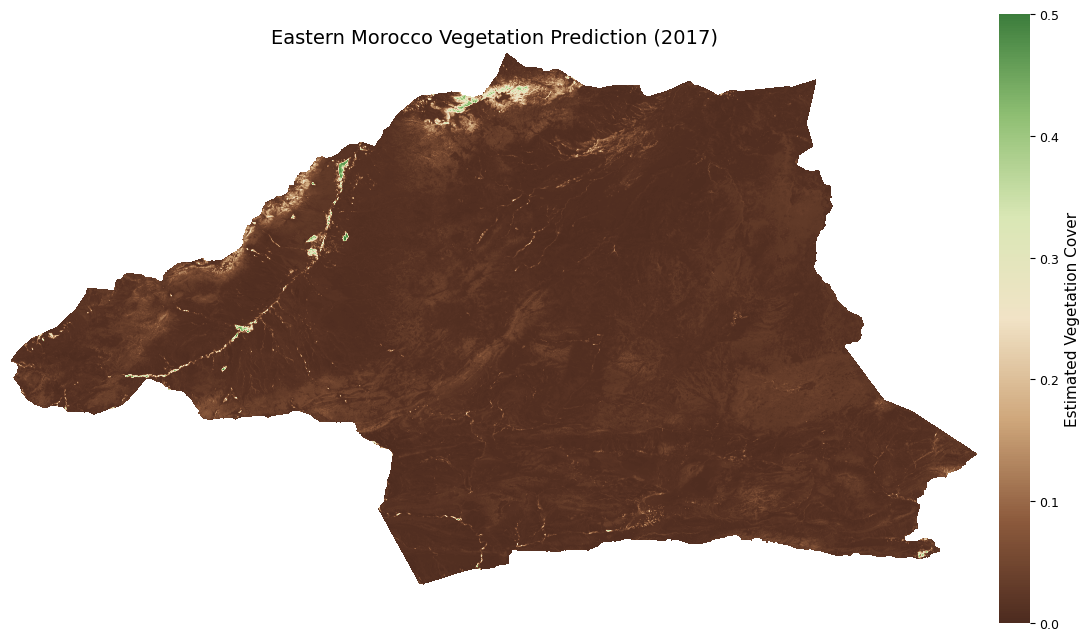

Raw min/max: 0.0 0.5
Figure saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\S2_RF_EM_frame_2018.png


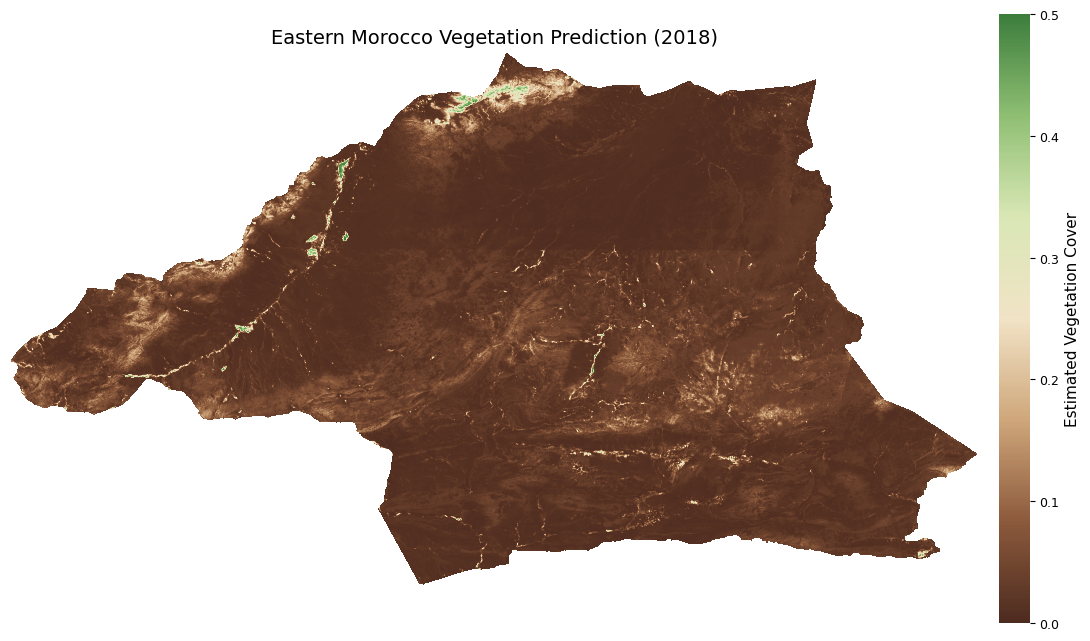

Raw min/max: 0.0 0.5
Figure saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\S2_RF_EM_frame_2019.png


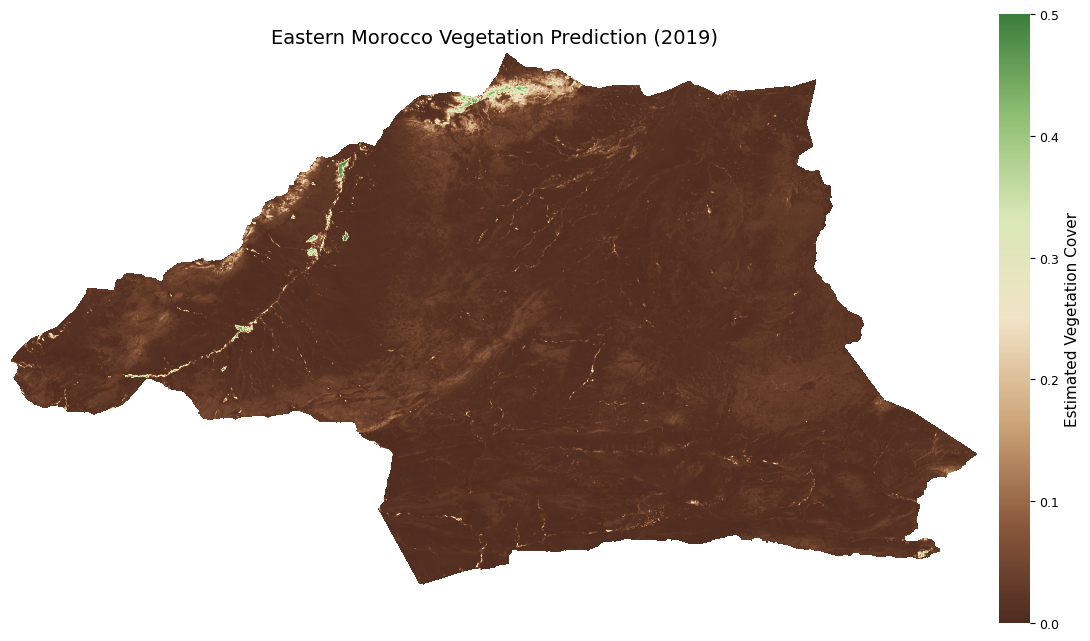

Raw min/max: 0.0 0.5
Figure saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\S2_RF_EM_frame_2020.png


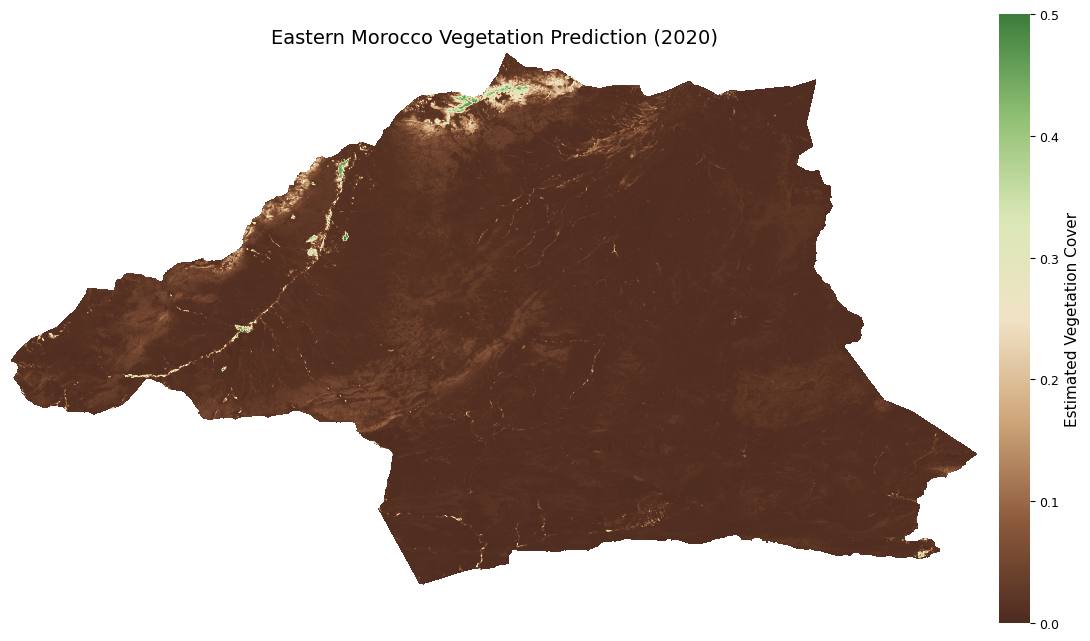

Raw min/max: 0.0 0.5
Figure saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\S2_RF_EM_frame_2021.png


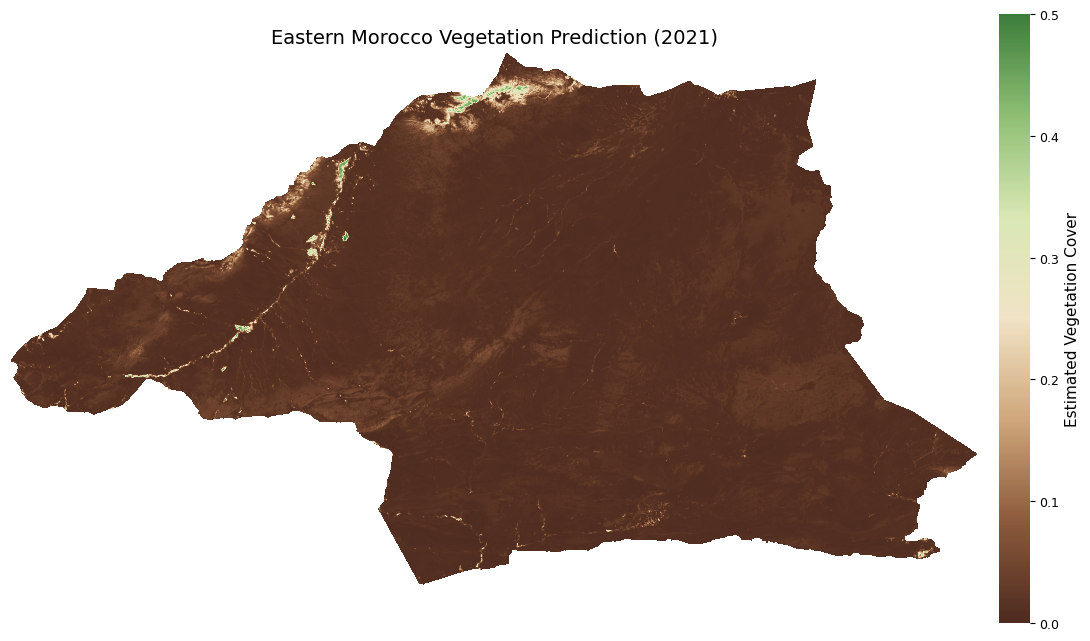

Raw min/max: 0.0 0.5
Figure saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\S2_RF_EM_frame_2022.png


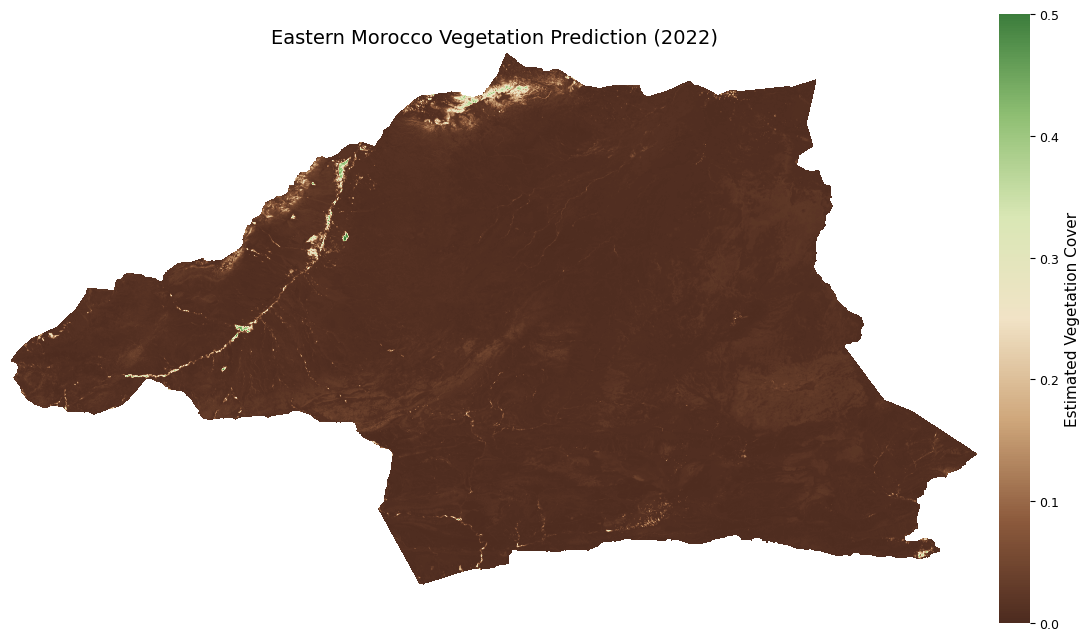

Raw min/max: 0.0 0.5
Figure saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\S2_RF_EM_frame_2023.png


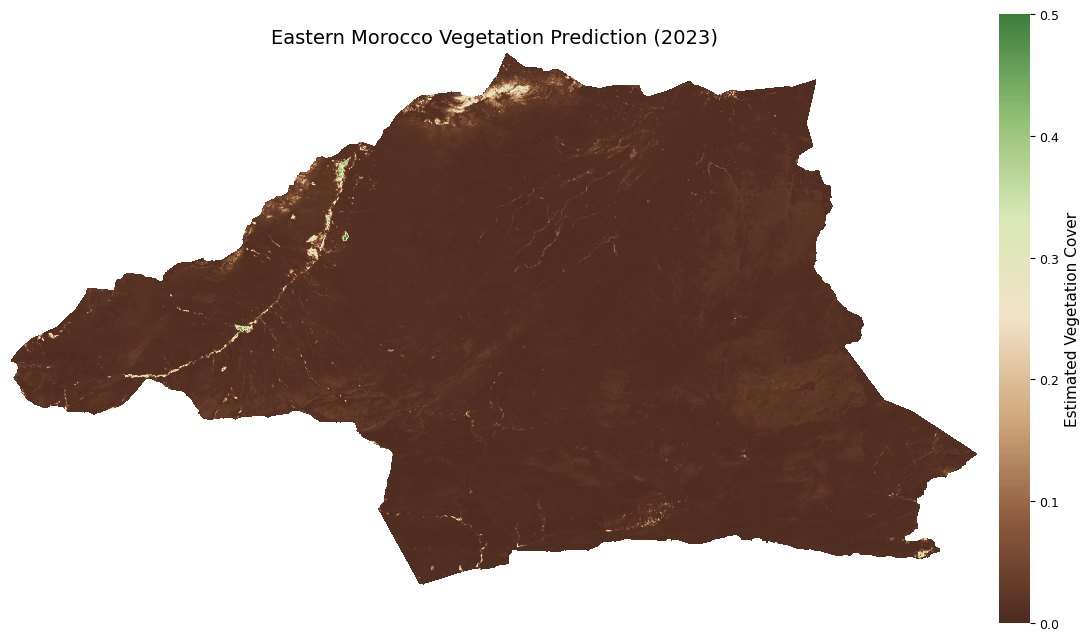

Raw min/max: 0.0 0.5
Figure saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\S2_RF_EM_frame_2024.png


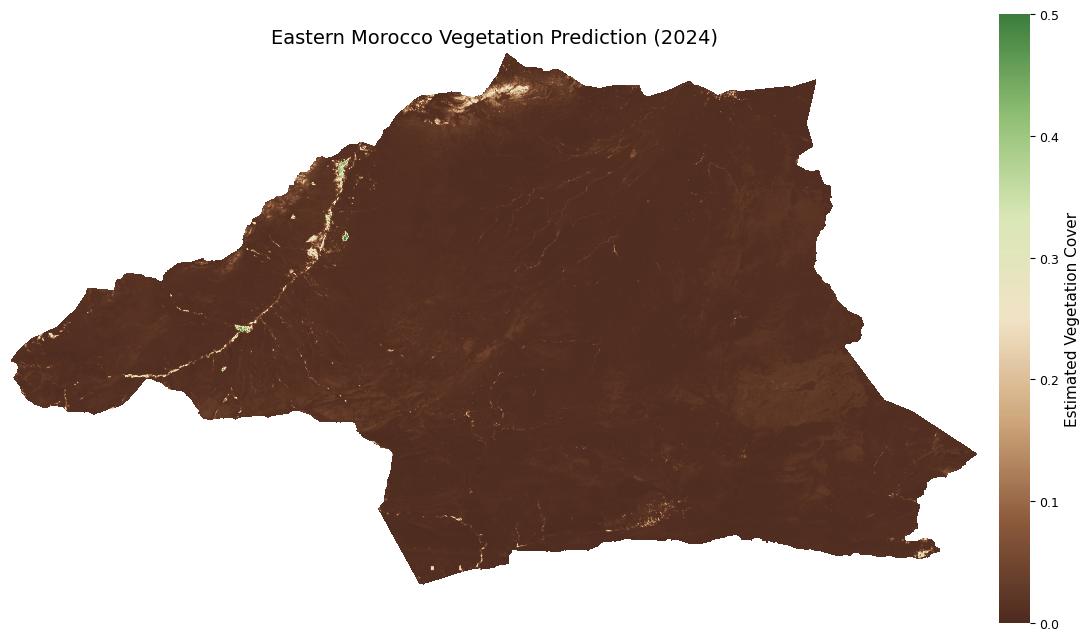

Raw min/max: 0.0 0.5
Figure saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\S2_RF_EM_frame_2025.png


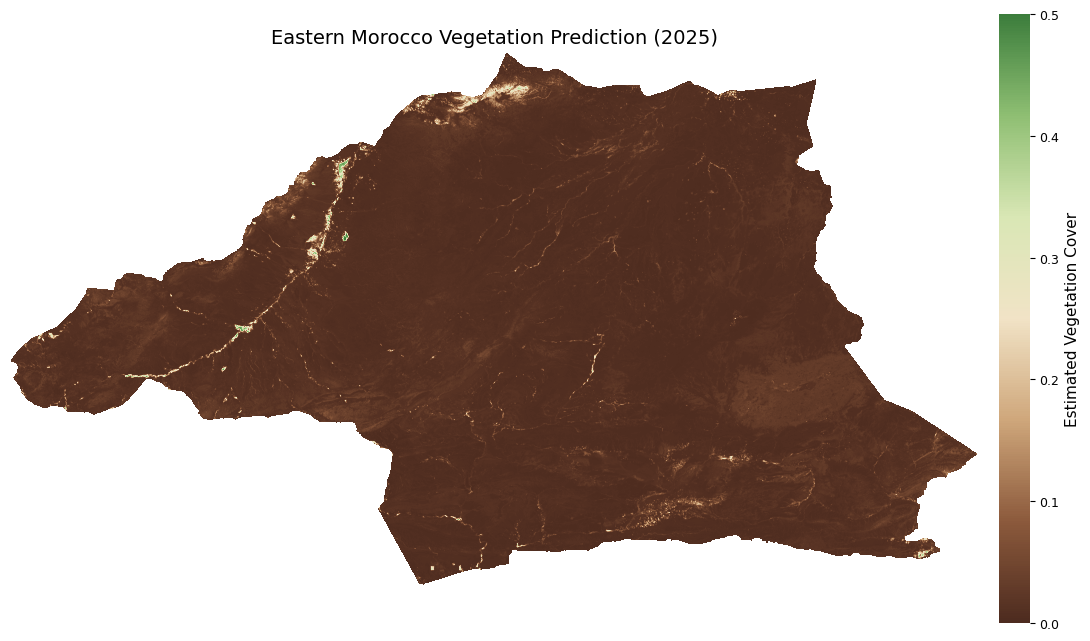

Raw min/max: 0.0 0.5


In [10]:
import os
from matplotlib.colors import LinearSegmentedColormap

folder = r'C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked'
years = range(2017, 2026)

colors = [
    "#4d2b1f",  # dark brown
    "#8c5a3c",  # brown
    "#cfa77b",  # tan
    "#f1e3c6",  # light cream
    "#d9e7b5",  # pale green
    "#8fbf73",  # green
    "#3c7d3c"   # dark green
]

cmap = LinearSegmentedColormap.from_list(
    'arcgis_elevation5',
    colors
)

for year in years:

    tif_path = os.path.join(
        folder,
        f"S2_RF_EM_{year}_masked.tif"
    )

    plot_veg_prediction_raw(
        tif_path=tif_path,
        cmap=cmap,
        year=year,
        save=True
    )

['C:\\Users\\PangY\\OneDrive - Smithsonian Institution\\Bustard\\01_Data\\GEE Satellite\\S2_Veg_Pred_EM\\30m\\30m_masked\\S2_RF_EM_frame_2017.png', 'C:\\Users\\PangY\\OneDrive - Smithsonian Institution\\Bustard\\01_Data\\GEE Satellite\\S2_Veg_Pred_EM\\30m\\30m_masked\\S2_RF_EM_frame_2018.png', 'C:\\Users\\PangY\\OneDrive - Smithsonian Institution\\Bustard\\01_Data\\GEE Satellite\\S2_Veg_Pred_EM\\30m\\30m_masked\\S2_RF_EM_frame_2019.png', 'C:\\Users\\PangY\\OneDrive - Smithsonian Institution\\Bustard\\01_Data\\GEE Satellite\\S2_Veg_Pred_EM\\30m\\30m_masked\\S2_RF_EM_frame_2020.png', 'C:\\Users\\PangY\\OneDrive - Smithsonian Institution\\Bustard\\01_Data\\GEE Satellite\\S2_Veg_Pred_EM\\30m\\30m_masked\\S2_RF_EM_frame_2021.png', 'C:\\Users\\PangY\\OneDrive - Smithsonian Institution\\Bustard\\01_Data\\GEE Satellite\\S2_Veg_Pred_EM\\30m\\30m_masked\\S2_RF_EM_frame_2022.png', 'C:\\Users\\PangY\\OneDrive - Smithsonian Institution\\Bustard\\01_Data\\GEE Satellite\\S2_Veg_Pred_EM\\30m\\30m_mask

In [16]:
import imageio.v2 as imageio
folder = r'C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked'
gif_path = os.path.join(folder,'Eastern_Morocco_Veg_Dynamics_2017_2025.gif')
years = range(2017,2026)
frames = []
for year in years:
    frame_path = os.path.join(
        folder,
        f'S2_RF_EM_frame_{year}.png'
    )
    # print(frame_path)
    # frames.append(frame_path)
    frames.append(imageio.imread(frame_path))
    
# print(frames)

imageio.mimsave(
    gif_path,
    frames,
    duration=1.2,
    loop=0
)

print('\nGIF saved:')
print(gif_path)


GIF saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\Eastern_Morocco_Veg_Dynamics_2017_2025.gif


In [15]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import imageio.v2 as imageio

# =====================================================
# 1. INPUT SETTINGS
# =====================================================
folder = r'C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked'

years = range(2017, 2026)

# =====================================================
# 2. OUTPUT FOLDER FOR GIF FRAMES
# =====================================================
frame_dir = os.path.join(folder, 'gif_frames')
os.makedirs(frame_dir, exist_ok=True)

# =====================================================
# 3. ArcGIS Elevation #5 Style Palette
# =====================================================
colors = [
    "#4d2b1f",  # dark brown
    "#8c5a3c",  # brown
    "#cfa77b",  # tan
    "#f1e3c6",  # light cream
    "#d9e7b5",  # pale green
    "#8fbf73",  # green
    "#3c7d3c"   # dark green
]

cmap = LinearSegmentedColormap.from_list(
    'arcgis_elevation5',
    colors
)

# =====================================================
# 4. GLOBAL MIN/MAX FOR CONSISTENT VISUALIZATION
# =====================================================
all_valid = []

print('Calculating global normalization range...')

for year in years:

    tif_files = [
        f for f in os.listdir(folder)
        if f.endswith('.tif') and str(year) in f
    ]

    print(tif_files)
    if len(tif_files) == 0:
        print(f'No TIFF found for {year}')
        continue

    tif_path = os.path.join(folder, tif_files[0])

    with rasterio.open(tif_path) as src:

        data = src.read(1).astype('float32')

        # remove nodata
        valid = data[data != -1]

        all_valid.extend(valid.flatten())

# robust global scaling
vmin = np.percentile(all_valid, 2)
vmax = np.percentile(all_valid, 98)

print('Global vmin:', vmin)
print('Global vmax:', vmax)

# =====================================================
# 5. PROCESS EACH YEAR
# =====================================================
frame_paths = []

for year in years:

    print(f'Processing {year}...')

    # -------------------------------------------------
    # Find TIFF
    # -------------------------------------------------
    tif_files = [
        f for f in os.listdir(folder)
        if f.endswith('.tif') and str(year) in f
    ]

    if len(tif_files) == 0:
        continue

    tif_path = os.path.join(folder, tif_files[0])

    # -------------------------------------------------
    # Read raster
    # -------------------------------------------------
    with rasterio.open(tif_path) as src:

        data = src.read(1).astype('float32')

    # -------------------------------------------------
    # Mask nodata for plotting
    # -------------------------------------------------
    data_masked = np.ma.masked_where(data == -1, data)

    # -------------------------------------------------
    # Normalize using GLOBAL scaling
    # -------------------------------------------------
    data_norm = (data_masked - vmin) / (vmax - vmin)
    data_norm = np.clip(data_norm, 0, 1)

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------
    plt.figure(figsize=(12, 9))

    img = plt.imshow(
        data_norm,
        cmap=cmap,
        vmin=0,
        vmax=1
    )

    cbar = plt.colorbar(img)
    cbar.set_label('Vegetation Prediction')

    plt.title(
        f'Eastern Morocco Vegetation Prediction ({year})',
        fontsize=16
    )

    plt.axis('off')
    plt.tight_layout()

    # -------------------------------------------------
    # Save frame
    # -------------------------------------------------
    frame_path = os.path.join(
        frame_dir,
        f'frame_{year}.png'
    )

    plt.savefig(
        frame_path,
        dpi=200,
        bbox_inches='tight'
    )

    plt.close()

    frame_paths.append(frame_path)

# =====================================================
# 6. CREATE GIF
# =====================================================
gif_path = os.path.join(
    folder,
    'Eastern_Morocco_Veg_Dynamics_2017_2025.gif'
)

frames = []

for fp in frame_paths:
    frames.append(imageio.imread(fp))

imageio.mimsave(
    gif_path,
    frames,
    duration=1.2,
    loop=0
)

print('\nGIF saved:')
print(gif_path)

Calculating global normalization range...
['S2_RF_EM_2017_masked.tif']
['S2_RF_EM_2018_masked.tif']
['S2_RF_EM_2019_masked.tif']
['S2_RF_EM_2020_masked.tif']
['S2_RF_EM_2021_masked.tif']
['S2_RF_EM_2022_masked.tif']
['S2_RF_EM_2023_masked.tif']
['S2_RF_EM_2024_masked.tif']
['S2_RF_EM_2025_masked.tif']
Global vmin: 0.002538717817515135
Global vmax: 0.09603306055068828
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...
Processing 2025...

GIF saved:
C:\Users\PangY\OneDrive - Smithsonian Institution\Bustard\01_Data\GEE Satellite\S2_Veg_Pred_EM\30m\30m_masked\Eastern_Morocco_Veg_Dynamics_2019_2024.gif
